Classes: ['pupunha', 'graviola', 'guarana', 'tucuma', 'acai', 'cupuacu']


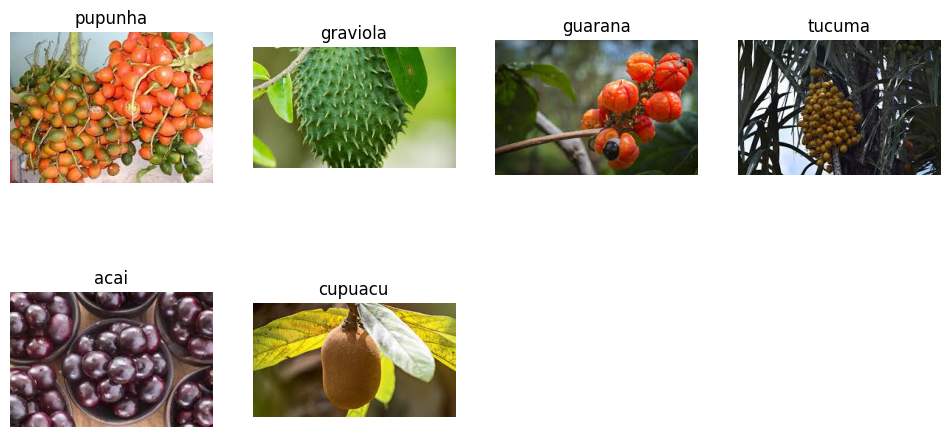

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/FruitinAmazon/train"

# Get class names
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes:", classes)

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    # List only files, ignore directories
    img_files = [f for f in os.listdir(class_path)
                 if os.path.isfile(os.path.join(class_path, f))]

    if not img_files:
        print(f"No images found in class folder: {cls}")
        continue

    img_name = random.choice(img_files)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Display images in a grid (2 rows)
plt.figure(figsize=(12,6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.show()

In [ ]:
# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Save class names before mapping
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Apply normalization
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1047 - loss: 1.8566
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 6s/step - accuracy: 0.1111 - loss: 1.8909 - val_accuracy: 0.0000e+00 - val_loss: 1.8534
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.1794 - loss: 1.8372
Epoch 2: val_accuracy improved from 0.00000 to 0.44444, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 559ms/step - accuracy: 0.1944 - loss: 1.7937 - val_accuracy: 0.4444 - val_loss: 1.5521
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.4230 - loss: 1.6466
Epoch 3: val_accuracy did not improve from 0.44444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 522ms/step - accuracy: 0.4722 - loss: 1.6327 - val_accuracy: 0.3333 - val_loss: 1.5524
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.5353 - loss: 1.4529
Epoch 4: val_accuracy improved from 0.44444 to 0.66667, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 568ms/step - accuracy: 0.5278 - loss: 1.4344 - val_accuracy: 0.6667 - val_loss: 1.3463
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.7089 - loss: 1.1945
Epoch 5: val_accuracy improved from 0.66667 to 0.83333, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step - accuracy: 0.7361 - loss: 1.1714 - val_accuracy: 0.8333 - val_loss: 0.7347
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.6892 - loss: 0.9161
Epoch 6: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 723ms/step - accuracy: 0.7083 - loss: 0.8872 - val_accuracy: 0.3889 - val_loss: 1.5199
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.8310 - loss: 0.6380
Epoch 7: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 811ms/step - accuracy: 0.8056 - loss: 0.6806 - val_accuracy: 0.8889 - val_loss: 0.5418
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8744 - loss: 0.4656
Epoch 8: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 547ms/step - accuracy: 0.8889 - loss: 0.4501 - val_accuracy: 0.6667 - val_loss: 0.5897
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9606 - loss: 0.2120
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 0.9444 - loss: 0.2443 - val_accuracy: 0.8333 - val_loss: 0.4414
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9902 - loss: 0.1416
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 538ms/step - accuracy: 0.9861 - loss: 0.1429 - val_accuracy: 0.8333 - val_loss: 0.3053
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9803 - loss: 0.

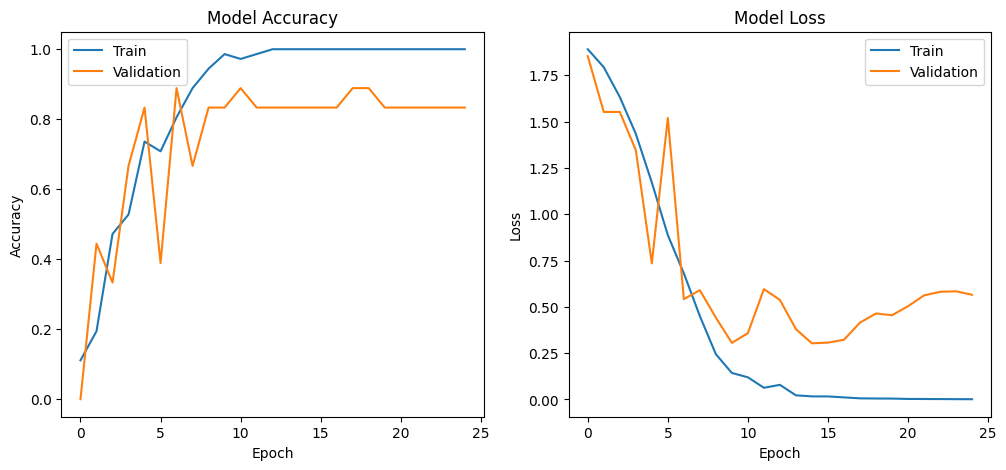

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8333 - loss: 0.3028
Test Accuracy: 0.8333333134651184
Test Loss: 0.30283722281455994


In [ ]:
model.save("fruit_cnn_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("fruit_cnn_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step - accuracy: 0.8333 - loss: 0.3028


[0.30283722281455994, 0.8333333134651184]

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

# Explicitly include all class labels
all_labels = list(range(len(class_names)))  # [0, 1, 2, 3, 4, 5]

report = classification_report(
    y_true,
    y_pred,
    labels=all_labels,       # ensures all classes are included
    target_names=class_names,
    zero_division=0          # avoids division by zero warnings
)

print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.67      0.67      0.67         3
      tucuma       0.93      0.87      0.90        15

    accuracy                           0.83        18
   macro avg       0.27      0.26      0.26        18
weighted avg       0.88      0.83      0.86        18

